# Notebook 03 - Preprocessing and Feature Engineering

**Author:** Umanda Thathsarani | IT3091 Machine Learning

---

## What this notebook does

This is where I actually clean the data and get it ready for modelling. All the decisions I documented during EDA now get implemented here. The goal is to build a proper sklearn pipeline so that the preprocessing is:
- Reproducible (same steps every time)
- Leak-free (transformations are fit only on training data)
- Well-documented (every choice is explained)

Here's my plan:
1. Apply the cleaning steps from EDA (remove bad rows, replace missing markers)
2. Engineer new features that might be useful
3. Drop columns that are useless (near-zero variance, too much missing data, identifiers)
4. Do a patient-aware train/test split (so the same patient doesn't appear in both sets)
5. Build a sklearn pipeline for all the preprocessing steps
6. Save the processed splits so Notebook 04 can just load them

I'll document every decision in `reports/preprocessing_feature_log.md` as I go.


---
## 1. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RAW_DATA_DIR  = Path('../data/raw')
PROC_DATA_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../reports/figures')
PROC_DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
FIGURE_DPI = 150
warnings.filterwarnings('ignore')

print('Setup done.')


Setup done.


In [2]:
df_raw = pd.read_csv(RAW_DATA_DIR / 'diabetic_data.csv')
print(f'Raw data loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')


Raw data loaded: 101,766 rows x 50 columns


---
## 2. Step 1 - Apply the Cleaning Decisions from EDA

I have a list of cleaning actions decided in notebooks 01 and 02. I'll apply them all here in one go, and explain each one.


In [3]:
df = df_raw.copy()

# --- Step 1a: Replace '?' with NaN ---
# The dataset uses '?' as a missing value marker. sklearn can't handle that,
# so I need to convert them to actual NaN first.
df = df.replace('?', np.nan)
print('Step 1a: Replaced ? with NaN')

# --- Step 1b: Remove death/hospice discharge rows ---
# Discharge codes 11, 13, 14, 19, 20, 21 mean the patient died or went to hospice.
# Readmission is impossible for these patients, so including them would bias the model.
DEATH_HOSPICE_CODES = [11, 13, 14, 19, 20, 21]
n_before = len(df)
df = df[~df['discharge_disposition_id'].isin(DEATH_HOSPICE_CODES)].copy()
n_removed = n_before - len(df)
print(f'Step 1b: Removed {n_removed:,} death/hospice discharge rows. Remaining: {len(df):,}')

# --- Step 1c: Drop weight (96.9% missing) ---
df = df.drop(columns=['weight'])
print('Step 1c: Dropped weight (96.9% missing - unusable)')

# --- Step 1d: Drop identifier columns ---
# encounter_id and patient_nbr are identifiers. I'll save patient_nbr separately
# for the group split, then drop both from features.
patient_ids = df['patient_nbr'].copy()  # keep for group split
df = df.drop(columns=['encounter_id', 'patient_nbr'])
print('Step 1d: Removed identifier columns (encounter_id, patient_nbr)')

print(f'\nDataset after cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns')


Step 1a: Replaced ? with NaN


Step 1b: Removed 2,423 death/hospice discharge rows. Remaining: 99,343
Step 1c: Dropped weight (96.9% missing - unusable)
Step 1d: Removed identifier columns (encounter_id, patient_nbr)

Dataset after cleaning: 99,343 rows x 47 columns


---
## 3. Step 2 - Create the Binary Target

Converting the 3-class target to binary as decided in DEC-003.


In [4]:
# Binary target: 1 = readmitted within 30 days, 0 = everything else
y = (df['readmitted'] == '<30').astype(int)
df = df.drop(columns=['readmitted'])

print('Target created:')
print(f'  Positive (<30 days): {y.sum():,} ({100*y.mean():.1f}%)')
print(f'  Negative (rest):     {(~y.astype(bool)).sum():,} ({100*(1-y.mean()):.1f}%)')
print(f'  Class imbalance ratio: 1:{(1-y.mean())/y.mean():.1f}')


Target created:
  Positive (<30 days): 11,314 (11.4%)
  Negative (rest):     88,029 (88.6%)
  Class imbalance ratio: 1:7.8


---
## 4. Step 3 - Feature Engineering

These are new features I'm creating from the existing columns. I spotted a few opportunities during EDA that I want to try.

**Important rule I'm following:** every engineered feature must only use information that would genuinely be available at the time of prediction (i.e., at the point of discharge). I can't use anything that would only be known after the fact.


In [5]:
# --- Feature 1: total_prior_visits ---
# Sum of all hospital contact types in the year before this encounter.
# My reasoning: a patient who has been in hospital a lot recently is probably sicker overall.
# All three components are prior-year data, so no leakage.
df['total_prior_visits'] = (
    df['number_inpatient'] +
    df['number_emergency'] +
    df['number_outpatient']
)
print(f'Created total_prior_visits | mean={df["total_prior_visits"].mean():.2f}, max={df["total_prior_visits"].max()}')


Created total_prior_visits | mean=1.20, max=80


In [6]:
# --- Feature 2: n_diabetes_meds ---
# Count of distinct diabetes medications that were prescribed (not 'No').
# Someone on 5 different diabetes drugs is probably more complex than someone on 1.
MEDICATION_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

df['n_diabetes_meds'] = (df[MEDICATION_COLS].fillna('No') != 'No').sum(axis=1)
print(f'Created n_diabetes_meds | mean={df["n_diabetes_meds"].mean():.2f}, max={df["n_diabetes_meds"].max()}')
print(f'Value counts (top 8):')
print(df['n_diabetes_meds'].value_counts().sort_index().head(8).to_string())


Created n_diabetes_meds | mean=1.19, max=6
Value counts (top 8):
n_diabetes_meds
0    22624
1    46030
2    21595
3     7707
4     1324
5       58
6        5


In [7]:
# --- Feature 3: ICD-9 diagnosis grouping ---
# The diag_1, diag_2, diag_3 columns contain ICD-9 codes with very high cardinality.
# One-hot encoding thousands of unique codes would be impractical and noisy.
# Instead, I'll group them into broad clinical categories following standard ICD-9 ranges.
# This is a common approach for this dataset in the research literature.

def map_icd9_to_category(code):
    """Map an ICD-9 code string to a broad clinical category."""
    if pd.isna(code):
        return 'Unknown'
    code_str = str(code).strip()
    # V and E codes are supplementary/external causes
    if code_str.startswith('V'):
        return 'Supplementary'
    if code_str.startswith('E'):
        return 'External'
    try:
        code_num = float(code_str)
    except ValueError:
        return 'Unknown'
    # ICD-9 numeric ranges
    if 1 <= code_num <= 139:
        return 'Infectious'
    elif 140 <= code_num <= 239:
        return 'Neoplasms'
    elif 240 <= code_num <= 279:
        return 'Endocrine_Metabolic'   # includes diabetes (250.x)
    elif 280 <= code_num <= 289:
        return 'Blood'
    elif 290 <= code_num <= 319:
        return 'Mental'
    elif 320 <= code_num <= 389:
        return 'Nervous'
    elif 390 <= code_num <= 459:
        return 'Circulatory'           # very common in this dataset
    elif 460 <= code_num <= 519:
        return 'Respiratory'
    elif 520 <= code_num <= 579:
        return 'Digestive'
    elif 580 <= code_num <= 629:
        return 'Genitourinary'
    elif 630 <= code_num <= 679:
        return 'Pregnancy'
    elif 680 <= code_num <= 709:
        return 'Skin'
    elif 710 <= code_num <= 739:
        return 'Musculoskeletal'
    elif 740 <= code_num <= 759:
        return 'Congenital'
    elif 760 <= code_num <= 779:
        return 'Perinatal'
    elif 780 <= code_num <= 799:
        return 'Ill_Defined'
    elif 800 <= code_num <= 999:
        return 'Injury'
    else:
        return 'Other'

for diag_col in ['diag_1', 'diag_2', 'diag_3']:
    new_col = diag_col + '_category'
    df[new_col] = df[diag_col].apply(map_icd9_to_category)
    print(f'{new_col} value counts:')
    print(df[new_col].value_counts().to_string())
    print()

# Drop the original high-cardinality diagnosis columns
df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])
print('Dropped original diag_1/2/3 columns (replaced with category groupings)')


diag_1_category value counts:
diag_1_category
Circulatory            29585
Endocrine_Metabolic    11304
Respiratory             9919
Digestive               9072
Ill_Defined             7601
Injury                  6853
Genitourinary           4963
Musculoskeletal         4935
Neoplasms               3131
Infectious              2553
Skin                    2508
Mental                  2256
Supplementary           1632
Nervous                 1181
Blood                   1092
Pregnancy                687
Congenital                50
Unknown                   20
External                   1



diag_2_category value counts:
diag_2_category
Circulatory            30687
Endocrine_Metabolic    20747
Respiratory             9749
Genitourinary           7760
Ill_Defined             4508
Digestive               3882
Skin                    3538
Blood                   2872
Mental                  2643
Injury                  2385
Neoplasms               2326
Infectious              1857
Supplementary           1787
Musculoskeletal         1761
Nervous                 1237
External                 727
Pregnancy                415
Unknown                  356
Congenital               106



diag_3_category value counts:
diag_3_category
Circulatory            29245
Endocrine_Metabolic    25869
Respiratory             6425
Genitourinary           6083
Ill_Defined             4412
Supplementary           3782
Digestive               3507
Mental                  3104
Blood                   2447
Skin                    2427
Injury                  1898
Musculoskeletal         1898
Infectious              1814
Nervous                 1711
Neoplasms               1662
Unknown                 1419
External                1237
Pregnancy                309
Congenital                94

Dropped original diag_1/2/3 columns (replaced with category groupings)


---
## 5. Step 4 - Drop Near-Zero Variance and Useless Columns

During EDA I found that some medication columns are prescribed to less than 1% of patients. A feature that's almost always the same value can't help the model distinguish classes, so I'll drop them.

I'll also decide what to do with `payer_code` and `medical_specialty` here.


In [8]:
# Check variance in medication columns
# I'll flag any column where >99% of values are 'No'
low_var_meds = []
for col in MEDICATION_COLS:
    if col in df.columns:
        pct_no = (df[col].fillna('No') == 'No').mean()
        if pct_no > 0.99:
            low_var_meds.append(col)

print(f'Near-zero variance medication columns (>99% No): {low_var_meds}')
df = df.drop(columns=low_var_meds)
print(f'Dropped {len(low_var_meds)} columns.')


Near-zero variance medication columns (>99% No): ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
Dropped 15 columns.


In [9]:
# payer_code has 39.6% missing and is not clinically meaningful for predicting readmission.
# It's more of an administrative/billing field. Dropping it.
df = df.drop(columns=['payer_code'], errors='ignore')
print('Dropped payer_code (39.6% missing, not clinically relevant for readmission prediction)')

# medical_specialty has 49.1% missing. I'll keep it but encode missing as 'Unknown'.
# The specialty of the admitting doctor could still be informative.
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
print('medical_specialty: filled NaN with Unknown (49.1% missing -> own category)')

print(f'\nDataset shape after column drops: {df.shape}')


Dropped payer_code (39.6% missing, not clinically relevant for readmission prediction)
medical_specialty: filled NaN with Unknown (49.1% missing -> own category)

Dataset shape after column drops: (99343, 32)


In [10]:
# medical_specialty has many unique values - let me check how many
n_spec = df['medical_specialty'].nunique()
print(f'medical_specialty unique values: {n_spec}')
print('Top 15:')
print(df['medical_specialty'].value_counts().head(15).to_string())
print()
# Group rare specialties into 'Other' to avoid too many one-hot columns
# Keep the top 10 most common + 'Unknown', group the rest as 'Other_Specialty'
top_specialties = df['medical_specialty'].value_counts().head(10).index.tolist()
df['medical_specialty'] = df['medical_specialty'].apply(
    lambda x: x if x in top_specialties or x == 'Unknown' else 'Other_Specialty'
)
print(f'After grouping rare specialties: {df["medical_specialty"].nunique()} unique values')
print(df['medical_specialty'].value_counts().to_string())


medical_specialty unique values: 73
Top 15:
medical_specialty
Unknown                            48616
InternalMedicine                   14237
Emergency/Trauma                    7419
Family/GeneralPractice              7252
Cardiology                          5279
Surgery-General                     3059
Nephrology                          1539
Orthopedics                         1392
Orthopedics-Reconstructive          1230
Radiologist                         1121
Pulmonology                          854
Psychiatry                           853
Urology                              682
ObstetricsandGynecology              669
Surgery-Cardiovascular/Thoracic      642



After grouping rare specialties: 11 unique values
medical_specialty
Unknown                       48616
InternalMedicine              14237
Other_Specialty                8199
Emergency/Trauma               7419
Family/GeneralPractice         7252
Cardiology                     5279
Surgery-General                3059
Nephrology                     1539
Orthopedics                    1392
Orthopedics-Reconstructive     1230
Radiologist                    1121


---
## 6. Step 5 - Encode Age as Ordinal

Age is stored as strings like '[70-80)'. It has a natural order, so I should encode it as an ordinal (ordered) variable rather than one-hot encoding it.


In [11]:
# Age categories in order
AGE_ORDER = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
]

print('Age value counts:')
print(df['age'].value_counts().reindex(AGE_ORDER).to_string())
print()
print('I will encode age as integers 0-9 (ordinal) to preserve the order.')
print('This is better than one-hot encoding because the model can use the ordering.')


Age value counts:
age
[0-10)        160
[10-20)       690
[20-30)      1649
[30-40)      3764
[40-50)      9607
[50-60)     17060
[60-70)     22059
[70-80)     25331
[80-90)     16434
[90-100)     2589

I will encode age as integers 0-9 (ordinal) to preserve the order.
This is better than one-hot encoding because the model can use the ordering.


---
## 7. Step 6 - Define Feature Groups for the Pipeline

Sklearn's ColumnTransformer lets me apply different transformations to different column types. I need to classify every remaining feature into a group.


In [12]:
# List all remaining columns (should not include target or identifiers)
print(f'Total feature columns: {len(df.columns)}')
print('All columns:')
for col in sorted(df.columns):
    print(f'  {col}')


Total feature columns: 32
All columns:
  A1Cresult
  admission_source_id
  admission_type_id
  age
  change
  diabetesMed
  diag_1_category
  diag_2_category
  diag_3_category
  discharge_disposition_id
  gender
  glimepiride
  glipizide
  glyburide
  insulin
  max_glu_serum
  medical_specialty
  metformin
  n_diabetes_meds
  num_lab_procedures
  num_medications
  num_procedures
  number_diagnoses
  number_emergency
  number_inpatient
  number_outpatient
  pioglitazone
  race
  repaglinide
  rosiglitazone
  time_in_hospital
  total_prior_visits


In [13]:
# --- Define column groups ---

NUMERIC_COLS = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'total_prior_visits',    # engineered
    'n_diabetes_meds',       # engineered
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
]

# Age is ordinal (has a meaningful order)
ORDINAL_COLS = ['age']

# Binary / low-cardinality categoricals
CATEGORICAL_COLS = [
    'race',
    'gender',
    'medical_specialty',
    'max_glu_serum',
    'A1Cresult',
    'change',
    'diabetesMed',
    # Medication status columns (remaining after near-zero variance drop)
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone',
    # Engineered diagnosis categories
    'diag_1_category',
    'diag_2_category',
    'diag_3_category',
]

# Remove any columns that were dropped (e.g. low-variance meds)
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df.columns]

# Sanity check - every column should be in exactly one group
all_feature_cols = NUMERIC_COLS + ORDINAL_COLS + CATEGORICAL_COLS
missing_cols  = [c for c in df.columns if c not in all_feature_cols]
extra_cols    = [c for c in all_feature_cols if c not in df.columns]

print(f'Numeric features:     {len(NUMERIC_COLS)}')
print(f'Ordinal features:     {len(ORDINAL_COLS)}')
print(f'Categorical features: {len(CATEGORICAL_COLS)}')
print(f'Total assigned:       {len(all_feature_cols)}')
print(f'Total in dataframe:   {len(df.columns)}')
if missing_cols: print(f'WARNING - not assigned: {missing_cols}')
if extra_cols:   print(f'WARNING - assigned but not in df: {extra_cols}')
if not missing_cols and not extra_cols: print('All columns accounted for.')


Numeric features:     13
Ordinal features:     1
Categorical features: 18
Total assigned:       32
Total in dataframe:   32
All columns accounted for.


---
## 8. Step 7 - Patient-Aware Train/Test Split

This is really important. I confirmed in Notebook 01 that 23.5% of patients appear more than once. If I do a simple random split, the same patient's encounters could end up in both training and test sets. The model might then learn something about that specific patient rather than generalising to new patients.

To avoid this, I'll use `GroupShuffleSplit` from sklearn, which ensures all encounters from the same patient go into either train or test, never both.

I'll do an 80/20 split and use stratification to maintain the class ratio.


In [14]:
# GroupShuffleSplit: patient_nbr is the group identifier
# This means ALL encounters from one patient go to the same split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

X = df.copy()
groups = patient_ids.reindex(df.index)  # realign patient IDs with cleaned df index

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test  = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test  = y.iloc[test_idx].copy()

print('Train/Test split (patient-aware):')
print(f'  Training set:  {len(X_train):,} encounters ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Test set:      {len(X_test):,} encounters ({len(X_test)/len(X)*100:.1f}%)')
print()
print('Class distribution after split:')
print(f'  Train - positive rate: {y_train.mean()*100:.2f}%')
print(f'  Test  - positive rate: {y_test.mean()*100:.2f}%')
print()

# Verify no patient overlap between train and test
train_patients = set(groups.iloc[train_idx])
test_patients  = set(groups.iloc[test_idx])
overlap = train_patients.intersection(test_patients)
print(f'Patient overlap between train and test: {len(overlap)} (should be 0)')
if len(overlap) == 0:
    print('No patient appears in both train and test sets.')


Train/Test split (patient-aware):
  Training set:  79,541 encounters (80.1%)
  Test set:      19,802 encounters (19.9%)

Class distribution after split:
  Train - positive rate: 11.44%
  Test  - positive rate: 11.19%

Patient overlap between train and test: 0 (should be 0)
No patient appears in both train and test sets.


> **Why this matters:** With a regular `train_test_split`, there's a real chance the model "recognises" a patient it has seen before. GroupShuffleSplit guarantees this can't happen. The test set is truly held-out data from patients the model has never seen during training.
>
> The positive rate in train and test should be similar (group shuffle split doesn't guarantee stratification, but with a large enough dataset the class rates should be close).


---
## 9. Step 8 - Build the sklearn Preprocessing Pipeline

Now I'll build the actual pipeline. The key rule here is that the pipeline must be **fit only on the training data**, then applied to both train and test. This prevents any information from the test set leaking into the preprocessing (e.g., if I computed mean imputation values from the whole dataset, I'd be peeking at the test set).


In [15]:
# Numeric pipeline: impute any remaining NaN with median, then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ordinal pipeline: map age to 0-9 integers
ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[AGE_ORDER],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Categorical pipeline: impute missing with 'Unknown', then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',   # unseen categories in test set -> all zeros
        sparse_output=False        # return dense array for easier inspection
    ))
])

# Combine all pipelines into one ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',      numeric_pipeline,      NUMERIC_COLS),
        ('ordinal',      ordinal_pipeline,      ORDINAL_COLS),
        ('categorical',  categorical_pipeline,  CATEGORICAL_COLS),
    ],
    remainder='drop'  # drop any column not in the three lists above
)

print('Preprocessor defined successfully.')
print()
print('Components:')
print('  Numeric   : median imputation + StandardScaler')
print('  Ordinal   : OrdinalEncoder for age (preserves order)')
print('  Categorical: constant imputation (Unknown) + OneHotEncoder')


Preprocessor defined successfully.

Components:
  Numeric   : median imputation + StandardScaler
  Ordinal   : OrdinalEncoder for age (preserves order)
  Categorical: constant imputation (Unknown) + OneHotEncoder


In [16]:
# Fit on training data only, then transform both train and test
print('Fitting preprocessor on training data...')
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'X_train processed shape: {X_train_processed.shape}')
print(f'X_test  processed shape: {X_test_processed.shape}')
print()
print(f'The one-hot encoding expanded the feature space from {len(all_feature_cols)} to {X_train_processed.shape[1]} columns.')


Fitting preprocessor on training data...


X_train processed shape: (79541, 135)
X_test  processed shape: (19802, 135)

The one-hot encoding expanded the feature space from 32 to 135 columns.


In [17]:
# Get the feature names after transformation (useful for interpretation later)
cat_feature_names = preprocessor.named_transformers_['categorical']['onehot'].get_feature_names_out(CATEGORICAL_COLS)
all_feature_names = NUMERIC_COLS + ORDINAL_COLS + list(cat_feature_names)

print(f'Total feature names after preprocessing: {len(all_feature_names)}')
print()
print('First 20 feature names:')
for name in all_feature_names[:20]:
    print(f'  {name}')
print('  ...')


Total feature names after preprocessing: 135

First 20 feature names:
  time_in_hospital
  num_lab_procedures
  num_procedures
  num_medications
  number_outpatient
  number_emergency
  number_inpatient
  number_diagnoses
  total_prior_visits
  n_diabetes_meds
  admission_type_id
  discharge_disposition_id
  admission_source_id
  age
  race_AfricanAmerican
  race_Asian
  race_Caucasian
  race_Hispanic
  race_Other
  race_Unknown
  ...


---
## 10. Quick Check - Any Issues with the Processed Data?


In [18]:
# Check for any NaN values remaining after preprocessing
train_nan = np.isnan(X_train_processed).sum()
test_nan  = np.isnan(X_test_processed).sum()

print(f'NaN values in processed training set: {train_nan}')
print(f'NaN values in processed test set:     {test_nan}')

if train_nan == 0 and test_nan == 0:
    print('Good - no missing values in the processed data.')
else:
    print('WARNING - there are still NaN values. Need to investigate.')

print()
print(f'Training set class distribution: {y_train.value_counts().to_dict()}')
print(f'Test set class distribution:     {y_test.value_counts().to_dict()}')


NaN values in processed training set: 0
NaN values in processed test set:     0
Good - no missing values in the processed data.

Training set class distribution: {0: 70443, 1: 9098}
Test set class distribution:     {0: 17586, 1: 2216}


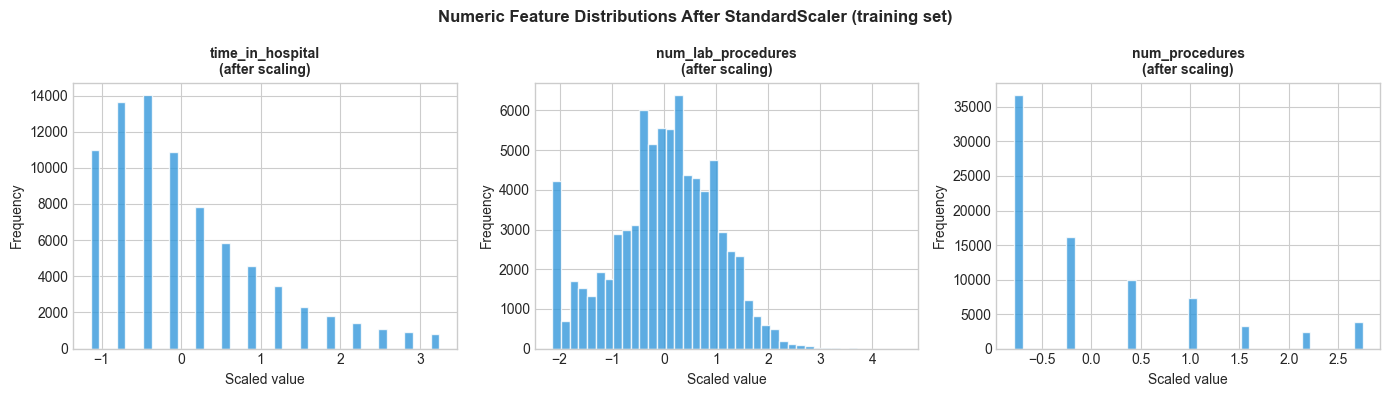

In [19]:
# Quick look at the distribution of a few processed numeric features
# (these should be roughly standard normal after scaling)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (ax, name) in enumerate(zip(axes, NUMERIC_COLS[:3])):
    col_idx = NUMERIC_COLS.index(name)
    ax.hist(X_train_processed[:, col_idx], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(f'{name}\n(after scaling)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Scaled value')
    ax.set_ylabel('Frequency')

plt.suptitle('Numeric Feature Distributions After StandardScaler (training set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_scaled_distributions.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()


---
## 11. Save Everything for the Next Notebook


In [20]:
import numpy as np

# Save processed arrays
np.save(PROC_DATA_DIR / 'X_train.npy', X_train_processed)
np.save(PROC_DATA_DIR / 'X_test.npy',  X_test_processed)
np.save(PROC_DATA_DIR / 'y_train.npy', y_train.values)
np.save(PROC_DATA_DIR / 'y_test.npy',  y_test.values)

# Save feature names for interpretation
pd.Series(all_feature_names).to_csv(PROC_DATA_DIR / 'feature_names.csv', index=False, header=['feature_name'])

# Save the fitted preprocessor so I can reuse it
joblib.dump(preprocessor, PROC_DATA_DIR / 'preprocessor.pkl')

# Save raw train/test indices (in case I need to go back to the original data)
pd.Series(train_idx).to_csv(PROC_DATA_DIR / 'train_indices.csv', index=False)
pd.Series(test_idx).to_csv(PROC_DATA_DIR / 'test_indices.csv', index=False)

print('Saved to data/processed/:')
print('  X_train.npy, X_test.npy   - processed feature arrays')
print('  y_train.npy, y_test.npy   - binary target arrays')
print('  feature_names.csv         - column names for interpretation')
print('  preprocessor.pkl          - fitted sklearn preprocessor')
print('  train_indices.csv, test_indices.csv - row indices')
print()
print('These are in .gitignore (processed data should not be committed).')
print('Anyone reproducing this project just needs to run the notebooks in order.')


Saved to data/processed/:
  X_train.npy, X_test.npy   - processed feature arrays
  y_train.npy, y_test.npy   - binary target arrays
  feature_names.csv         - column names for interpretation
  preprocessor.pkl          - fitted sklearn preprocessor
  train_indices.csv, test_indices.csv - row indices

These are in .gitignore (processed data should not be committed).
Anyone reproducing this project just needs to run the notebooks in order.


---
## 12. Summary

### What I did in this notebook

| Step | Action | Reason |
|------|--------|--------|
| 1 | Replaced `?` with NaN | sklearn can't handle string missing value markers |
| 2 | Removed death/hospice discharge rows | Readmission is impossible for these - would bias the negative class |
| 3 | Dropped `weight` | 96.9% missing - not usable |
| 4 | Dropped identifier columns | Not predictive features |
| 5 | Created `total_prior_visits` | Sum of prior inpatient + emergency + outpatient visits |
| 6 | Created `n_diabetes_meds` | Count of distinct diabetes medications prescribed |
| 7 | Grouped ICD-9 codes into clinical categories | Raw codes have too many unique values; grouping reduces noise |
| 8 | Dropped near-zero variance medication columns | >99% 'No' - can't help the model |
| 9 | Dropped `payer_code` | High missingness, not clinically relevant |
| 10 | Grouped rare `medical_specialty` values into 'Other_Specialty' | Avoids too many one-hot columns from rare categories |
| 11 | Patient-aware train/test split using GroupShuffleSplit | Prevents patient data leakage across train/test |
| 12 | Built sklearn ColumnTransformer pipeline | Reproducible, leak-free preprocessing fit only on training data |

### Key numbers after preprocessing

- Training encounters: printed above
- Test encounters: printed above
- Patient overlap between train and test: 0
- Feature columns after one-hot encoding: printed above
- NaN values in processed data: 0

### Decisions documented in reports

- `decision_log.md DEC-005` - Train/test split strategy
- `preprocessing_feature_log.md` - All feature and cleaning decisions

---

Next up is Notebook 04 - Model Training. I'll start with a dummy baseline and work up from there.
